Running serial: ./serial fake_test.csv
ICD9_CODE_1,total_patients,total_deaths,death_rate
42731,427,220,0.515222
5990,440,236,0.536364
71590,432,225,0.520833
78079,421,206,0.489311
25000,444,229,0.515766
2768,447,232,0.519016
496,397,194,0.488665
71536,442,222,0.502262
4019,442,234,0.529412
2449,466,229,0.491416
7242,465,242,0.52043
4280,461,222,0.481562
41401,444,212,0.477477
53081,1306,657,0.503063
51881,442,230,0.520362
5849,426,205,0.481221
49390,427,217,0.508197
5859,437,202,0.462243
486,390,184,0.471795
2724,441,220,0.498866
2720,403,191,0.473945
serial finished in 22.172 ms

Running openmp: OMP_NUM_THREADS=4 ./openmp fake_test.csv
ICD9_CODE_1,total_patients,total_deaths,death_rate
2720,403,191,0.473945
2724,441,220,0.498866
486,390,184,0.471795
5859,437,202,0.462243
49390,427,217,0.508197
5849,426,205,0.481221
51881,442,230,0.520362
42731,427,220,0.515222
53081,1306,657,0.503063
41401,444,212,0.477477
5990,440,236,0.536364
71590,432,225,0.520833
78079,421,206,0.489311
25000,444,

[serial] elapsed_ms=16.7868
[openmp] threads=4 elapsed_ms=17.3057
[pthread] threads=4 elapsed_ms=17.2984


ICD9_CODE_1,total_patients,total_deaths,death_rate
5849,426,205,0.481221
49390,427,217,0.508197
5990,440,236,0.536364
71590,432,225,0.520833
2768,447,232,0.519016
496,397,194,0.488665
71536,442,222,0.502262
51881,442,230,0.520362
42731,427,220,0.515222
4280,461,222,0.481562
41401,444,212,0.477477
53081,1306,657,0.503063
4019,442,234,0.529412
7242,465,242,0.52043
2449,466,229,0.491416
5859,437,202,0.462243
486,390,184,0.471795
2720,403,191,0.473945
2724,441,220,0.498866
25000,444,229,0.515766
78079,421,206,0.489311
mpi finished in 633.235 ms


================ Runtime Summary ================
serial  : 22.172 ms
openmp  : 21.977 ms
pthread : 21.589 ms
mpi     : 633.235 ms



[mpi] ranks=4 elapsed_ms=6.11887


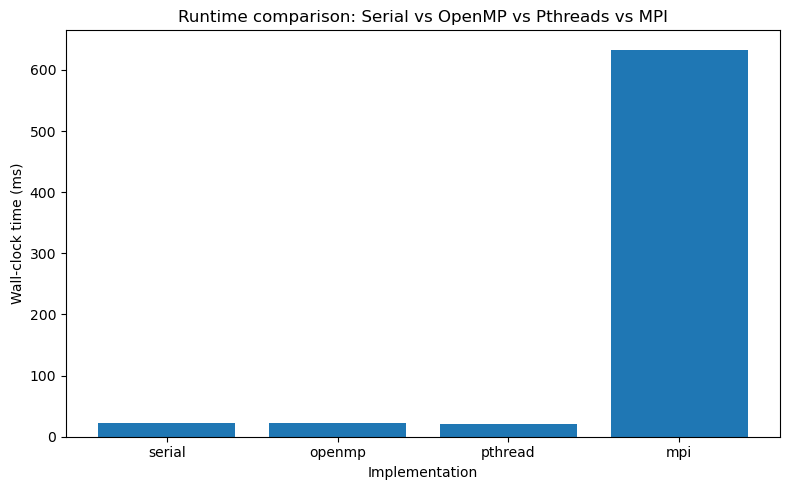

In [1]:
import subprocess
import time
import pandas as pd
import matplotlib.pyplot as plt

# Optional: build all implementations via Makefile
# Uncomment this if you have a Makefile with these targets.
def build_binaries():
    # Adjust this depending on your Makefile
    # For example, if your Makefile builds all four with "make":
    #   all: icd9_serial icd9_openmp icd9_pthread icd9_mpi
    print("Building binaries with make...")
    result = subprocess.run("make -j4", shell=True)
    if result.returncode != 0:
        raise RuntimeError("Build failed. Check your Makefile and compiler errors.")
    print("Build finished.\n")


def run_and_time(cmd, label):
    """
    Run a shell command and measure wall-clock time in milliseconds.
    """
    print(f"Running {label}: {cmd}")
    t0 = time.perf_counter()
    result = subprocess.run(cmd, shell=True)
    t1 = time.perf_counter()
    elapsed_ms = (t1 - t0) * 1000.0

    if result.returncode != 0:
        print(f"[WARN] {label} exited with code {result.returncode}")

    print(f"{label} finished in {elapsed_ms:.3f} ms\n")
    return elapsed_ms


def main():
  
    implementations = [
        ("serial",  "./serial fake_test.csv"),
        ("openmp",  "OMP_NUM_THREADS=4 ./openmp fake_test.csv"),
        ("pthread", "./pthreads fake_test.csv 4"),
        ("mpi",     "mpirun -np 4 ./mpi fake_test.csv"),
    ]

    rows = []
    for label, cmd in implementations:
        elapsed = run_and_time(cmd, label)
        rows.append((label, elapsed))

    df = pd.DataFrame(rows, columns=["implementation", "elapsed_ms"])

    print("\n================ Runtime Summary ================")
    for _, row in df.iterrows():
        print(f"{row['implementation']:8s}: {row['elapsed_ms']:.3f} ms")
    print("================================================\n")

    plt.figure(figsize=(8, 5))
    plt.bar(df["implementation"], df["elapsed_ms"])
    plt.xlabel("Implementation")
    plt.ylabel("Wall-clock time (ms)")
    plt.title("Runtime comparison: Serial vs OpenMP vs Pthreads vs MPI")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
